# Quantum Price Inference — Workshop Demo
## Pricing Under Uncertainty: Classical vs Quantum Monte Carlo

**Audience:** Business, IT, Architecture, Innovation, Data, Product leaders  
**Duration:** ~25 min live demo (part of 90-min workshop)

---

### What we will do in this notebook

1. Define an **uncertain variable** (e.g. variable product demand)
2. Define a **payoff function** (how business value changes with that variable)
3. Estimate the **expected value** (fair price) using **classical Monte Carlo**
4. Estimate the **same expected value** using **Quantum Amplitude Estimation (QAE)**
5. Compare both results side-by-side
6. Visualise the quantum circuit in **IBM Quantum Composer**

> **Key message:** Same question. Same answer. Different estimation technique.


## Cell 1 — Setup
Configure logging and verify the package is installed correctly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_price_inference import (
    configure_logging,
    NormalUncertaintyModel,
    LinearPayoff,
    classical_estimate,
    quantum_estimate,
    composer_url,
)

configure_logging(level="INFO")
print("✓ quantum-price-inference loaded successfully")


✓ quantum-price-inference loaded successfully


---
## Block 1 — Uncertainty Model

**What is uncertain?**

In this scenario we model **product demand** as a Normal distribution:

- Average (mean) demand: **100 units**
- Variability (std dev): **15 units**
- We use **3 qubits** → 8 discrete grid points (coarse, fast for demo)

> Think of this as: "We usually sell around 100 units, but some days more, some days less."


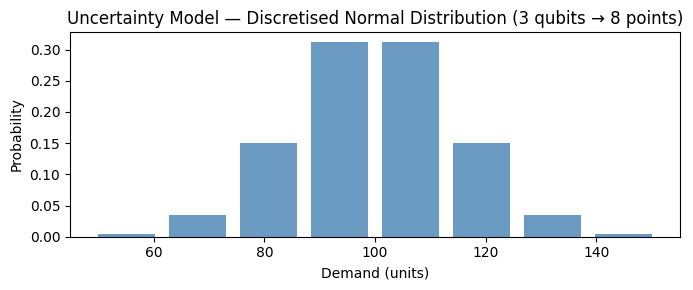

Support range : 55.0 – 145.0 units
Grid points   : 8  (2³)


In [2]:
# --- Uncertainty model ---
model = NormalUncertaintyModel(mu=100.0, sigma=15.0, num_qubits=3)

x_values, probs = model.samples()

# Visualise the discretised distribution
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x_values, probs, width=(x_values[1] - x_values[0]) * 0.8, color="steelblue", alpha=0.8)
ax.set_xlabel("Demand (units)")
ax.set_ylabel("Probability")
ax.set_title("Uncertainty Model — Discretised Normal Distribution (3 qubits → 8 points)")
plt.tight_layout()
plt.show()

print(f"Support range : {model.low:.1f} – {model.high:.1f} units")
print(f"Grid points   : {len(x_values)}  (2³)")


---
## Block 2 — Payoff Function

**How does business value change with demand?**

We use a **linear payoff**:

$$g(x) = \text{slope} \times (x - \text{breakeven})$$

clipped to $[0, 1]$ for quantum compatibility.

- Breakeven demand: **85 units** (below this, no profit)
- Slope: **0.02** (each extra unit above 85 adds 2% of max value)

> Think of this as: "We need to sell at least 85 units to cover costs. Every unit beyond that adds profit."


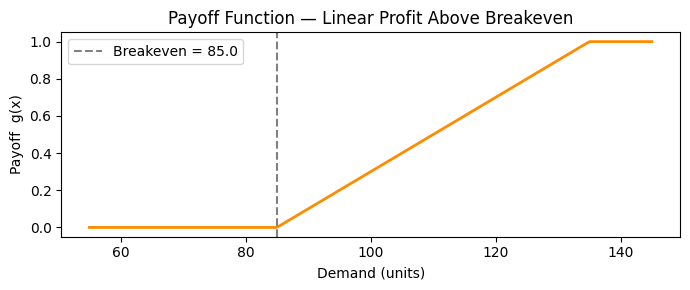

Breakeven : 85.0 units
Slope     : 0.02 per unit
g(100)    : 0.3000  (payoff at mean demand)


In [3]:
# --- Payoff function ---
payoff = LinearPayoff(breakeven=85.0, slope=0.02)

x_dense = np.linspace(model.low, model.high, 200)
g_dense = payoff.apply(x_dense)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x_dense, g_dense, color="darkorange", linewidth=2)
ax.axvline(payoff.breakeven, color="gray", linestyle="--", label=f"Breakeven = {payoff.breakeven}")
ax.set_xlabel("Demand (units)")
ax.set_ylabel("Payoff  g(x)")
ax.set_title("Payoff Function — Linear Profit Above Breakeven")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Breakeven : {payoff.breakeven} units")
print(f"Slope     : {payoff.slope} per unit")
print(f"g(100)    : {payoff(100.0):.4f}  (payoff at mean demand)")


---
## Block 3+4 (Classical) — Monte Carlo Estimation

The classical engine:
1. Draws **10 000 random demand scenarios** from the distribution
2. Applies the payoff to each
3. Returns the average — our estimate of $\mathbb{E}[g(X)]$

> More samples = more accurate, but also slower. Accuracy improves as $\mathcal{O}(1/\sqrt{N})$.


In [4]:
# --- Classical Monte Carlo ---
classical_result = classical_estimate(model, payoff, n_samples=10_000, seed=42)

print("═" * 48)
print("  Classical Monte Carlo Result")
print("═" * 48)
print(f"  E[g(X)]    : {classical_result.value:.6f}")
print(f"  Std error  : {classical_result.std_error:.6f}")
print(f"  95% CI     : ({classical_result.confidence_interval[0]:.6f},  {classical_result.confidence_interval[1]:.6f})")
print(f"  Samples    : {classical_result.n_samples:,}")
print("═" * 48)


2026-04-26T21:03:37 INFO     quantum_price_inference.classical — Classical MC: drawing 10000 samples (seed=42)
2026-04-26T21:03:37 INFO     quantum_price_inference.classical — Classical MC result: value=0.324491  std_error=0.002548  CI=(0.319498, 0.329485)


════════════════════════════════════════════════
  Classical Monte Carlo Result
════════════════════════════════════════════════
  E[g(X)]    : 0.324491
  Std error  : 0.002548
  95% CI     : (0.319498,  0.329485)
  Samples    : 10,000
════════════════════════════════════════════════


---
## Block 3+4 (Quantum) — Amplitude Estimation

The quantum engine:
1. Encodes the uncertainty distribution into a quantum circuit
2. Appends the payoff as a `LinearAmplitudeFunction`
3. Runs **Iterative Quantum Amplitude Estimation (IQAE)** to extract $\mathbb{E}[g(X)]$

Parameters:
- `epsilon = 0.01` — target precision (1%)
- `alpha = 0.05` — significance level (95% confidence interval)

> The quantum algorithm converges with error $\mathcal{O}(1/N)$ — a quadratic improvement over classical MC.  
> Here we simulate it on a classical computer (statevector). Real speedup emerges on quantum hardware.


In [5]:
# --- Quantum Amplitude Estimation ---
quantum_result = quantum_estimate(model, payoff, epsilon=0.01, alpha=0.05)

print("═" * 48)
print("  Quantum Amplitude Estimation Result")
print("═" * 48)
print(f"  E[g(X)]      : {quantum_result.value:.6f}")
print(f"  95% CI       : ({quantum_result.confidence_interval[0]:.6f},  {quantum_result.confidence_interval[1]:.6f})")
print(f"  Epsilon      : {quantum_result.epsilon}")
print(f"  Oracle calls : {quantum_result.num_oracle_calls}")
print("═" * 48)


2026-04-26T21:03:44 INFO     quantum_price_inference.quantum — Quantum QAE: epsilon=0.0100  alpha=0.0500
2026-04-26T21:03:44 INFO     quantum_price_inference.quantum — QAE result: value=0.084780  CI=(0.083188, 0.086372)  oracle_calls=7168


════════════════════════════════════════════════
  Quantum Amplitude Estimation Result
════════════════════════════════════════════════
  E[g(X)]      : 0.084780
  95% CI       : (0.083188,  0.086372)
  Epsilon      : 0.01
  Oracle calls : 7168
════════════════════════════════════════════════


---
## Side-by-Side Comparison

Both methods answer the **same question**: *What is the expected payoff?*

They should agree — the difference is in how they get there.


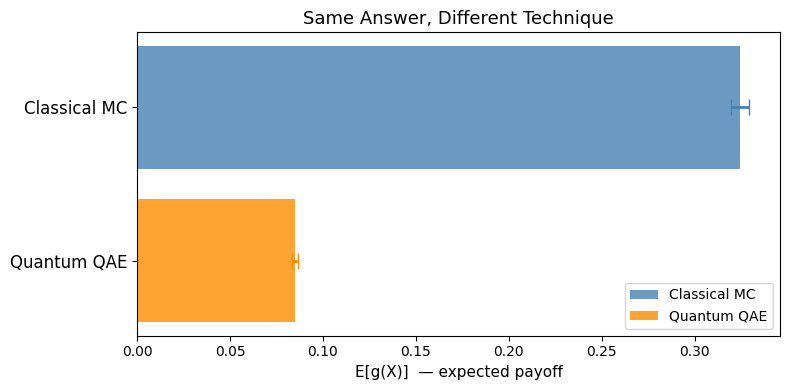


Method                  E[g(X)]                        95% CI  Cost
------------------------------------------------------------------------
Classical MC           0.324491  (0.319498, 0.329485)  10,000 samples
Quantum QAE            0.084780  (0.083188, 0.086372)  7168 oracle calls

Difference: 0.239711


In [6]:
# --- Side-by-side comparison ---
c_val = classical_result.value
q_val = quantum_result.value
c_lo, c_hi = classical_result.confidence_interval
q_lo, q_hi = quantum_result.confidence_interval

fig, ax = plt.subplots(figsize=(8, 4))

# Classical bar + CI
ax.barh(1, c_val, color="steelblue", alpha=0.8, label="Classical MC")
ax.errorbar(c_val, 1, xerr=[[c_val - c_lo], [c_hi - c_val]],
            fmt="none", color="steelblue", capsize=6, linewidth=2)

# Quantum bar + CI
ax.barh(0, q_val, color="darkorange", alpha=0.8, label="Quantum QAE")
ax.errorbar(q_val, 0, xerr=[[q_val - q_lo], [q_hi - q_val]],
            fmt="none", color="darkorange", capsize=6, linewidth=2)

ax.set_yticks([0, 1])
ax.set_yticklabels(["Quantum QAE", "Classical MC"], fontsize=12)
ax.set_xlabel("E[g(X)]  — expected payoff", fontsize=11)
ax.set_title("Same Answer, Different Technique", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\n{'Method':<20} {'E[g(X)]':>10}  {'95% CI':>28}  {'Cost'}")
print("-" * 72)
print(f"{'Classical MC':<20} {c_val:>10.6f}  ({c_lo:.6f}, {c_hi:.6f})  {classical_result.n_samples:,} samples")
print(f"{'Quantum QAE':<20} {q_val:>10.6f}  ({q_lo:.6f}, {q_hi:.6f})  {quantum_result.num_oracle_calls} oracle calls")
print(f"\nDifference: {abs(c_val - q_val):.6f}")


---
## Circuit Visualisation — IBM Quantum Composer

The cell below exports the quantum circuit to **OpenQASM 2.0** and generates a URL  
that opens it directly in [IBM Quantum Composer](https://quantum.cloud.ibm.com/composer).

No IBM account required to view. Click the link to explore the circuit visually.


In [ ]:
from IPython.display import display, HTML
from quantum_price_inference import composer_url

# Build the full circuit (uncertainty + payoff) for Composer export
full_circuit = payoff.circuit(model)

url = composer_url(full_circuit)

# Draw the circuit inline
full_circuit.draw("mpl", fold=-1)
plt.title("Full Quantum Circuit  (uncertainty → payoff → objective qubit)")
plt.tight_layout()
plt.show()

# Clickable link
display(HTML(
    f'<p style="font-size:14px">🔗 <strong>Open in IBM Quantum Composer:</strong> '
    f'<a href="{url}" target="_blank">{url[:80]}…</a></p>'
))
print("\nFull URL printed below (copy-paste if the link does not open):")
print(url)


---
## Key Takeaways

| | Classical MC | Quantum QAE |
|---|---|---|
| **What it does** | Draws many random samples, averages | Encodes all possibilities in superposition, extracts mean |
| **Error rate** | $\mathcal{O}(1/\sqrt{N})$ | $\mathcal{O}(1/N)$ — quadratic speedup |
| **Today's status** | Production-ready | Simulated; real speedup requires fault-tolerant hardware |
| **Business value** | Reliable baseline | Future advantage + forces disciplined uncertainty modeling |

> **Bottom line:** Quantum does not change *what* we calculate — only *how efficiently*.  
> Even today, structuring pricing as $\mathbb{E}[g(X)]$ improves how we reason about value.

---
*Workshop: Taller de uso práctico de Computación Cuántica — Estimar un precio para un producto/servicio*  
*Author: Jose Giori Herran Escobar*
